# Neurotransmitter Probability Variance across Drosophila Neuropils

This projects aims to answer - how do neurotransmitter probability distributions vary across neuropils in Drosophila?
The datasets should be downloaded into the data directory following the instructions on GitHub. 

## Stage 0: Set up environment

In [18]:
%load_ext autoreload 
%autoreload 2

# Import external libraries
import dask
from IPython.core.display import HTML, Image
from IPython.display import IFrame
import pyvista as pv
from dask.distributed import Client

# Import core python libraries
import os

# Import local scripts (brainz.py, pipeline.py, plotting.py, 
# preprocess.py)
from scripts import *

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


ImportError: cannot import name 'IFrame' from 'IPython.core.display' (C:\Users\cielb\anaconda3\envs\nta2\Lib\site-packages\IPython\core\display.py)

In [2]:
# Set up in-line 3D plot rendering
pv.set_jupyter_backend("trame")

In [3]:
# Set globals
OUTDIR = os.path.join(os.path.dirname(__name__), "results", "notebook")
if not os.path.exists(OUTDIR): os.mkdir(OUTDIR)
MINSIZE = 30 # Minimum number of nodes in a cluster/community

In [4]:
allow_bytes = pipeline.get_ram_allowance() # Allow Dask to use just over 60% of system RAM
PARTITION_SIZE = pipeline.get_partition_size(num_threads = 4, allow_bytes = allow_bytes)
client = pipeline.start_dask(num_threads = 4, allow_bytes = allow_bytes)
dask.config.set({"dataframe.shuffle.method": "tasks"})
preprocess.run() # ~10 mins first run

15.8 GiB available on machine; allowing 9.5 GiB

Dask Dashboard at http://192.168.0.134:8787/status

Notice: this may take some time if this is the first time running preprocess.py.


14:58:50 Preprocessing complete!


2026-06-01 15:03:14,290 - distributed.worker.memory - WARNING - Worker is at 80% memory usage. Pausing worker.  Process memory: 7.64 GiB -- Worker memory limit: 9.48 GiB
2026-06-01 15:03:14,645 - distributed.worker.memory - WARNING - Worker is at 73% memory usage. Resuming worker. Process memory: 6.97 GiB -- Worker memory limit: 9.48 GiB


## Stage 1: Load Data

This stage of the pipeline loads and merges data from file, creating a single cohesive dataframe containing metadata for every synapse belonging to a neuron-neuron connection in proofread_connections_783.parquet. 

Neurotransmitter probability normalisation is required because the probabilities of some points do not sum to exactly 1 across all 6 neurotransmitters, but Dirichlet regression and composition analysis requires these probabilities to sum to exactly 1. Additionally, neurotransmitter normalisation reduces the data from 6 compositional variables to 3 compositional variables: GABA, an inhibitory neurotransmitter; Acetylcholine ('ach'), an excitatory neurotransmitter, and 'other', which encompasses the remaining neurotransmitters which cannot be reliably classified as solely inhibitory or excitatory (rather, they are usually neuromodulators).

Although the proofread connections file contains a compact representation of synapse data already (synapse count, and the same neurotransmitter probabilities allocated to each synapse), this stage of the pipeline expands the compact representation back to representing one synapse per row. This is because compositional analysis of neurotransmitter probabilities across synapses (e.g., in Dirichlet regression and in plotting ternary plots) requires this expanded format. 

In [5]:
# Choose dataset to use. Note the decisions made in this notebook are based
# on the full connectome dataset (proofread_connections_783.parquet). The
# other datasets are selections of different neuropils, and are provided for
# debugging/testing purposes.

#DATASET = "data/proofread_connections_783.parquet" # ~ 1.05 GB

#DATASET = "data/large.parquet" # ~ 583 MB
#DATASET = "data/medium.parquet" # ~ 272 MB
#DATASET = "data/small.parquet" # ~ 56 MB
DATASET = "data/tiny.parquet" # ~ 215 KB

In [6]:
pipeline.relax_memory_limits() # Let Dask use a higher percentage of allocated RAM

In [7]:
connectome = pipeline.load_connectome(DATASET, PARTITION_SIZE)
connectome.head(3, npartitions=1).style.hide(axis="index")

14:58:51 Loading connectome ...
14:59:08 Connectome loaded


pre,post,neuropil,gaba,ach,glut,oct,ser,da
720575940629970489,720575940631267655,AVLP_R,0.654330,0.023704,0.272418,0.048125,0.000472,0.000951
720575940623828999,720575940612348950,SLP_R,0.386517,0.024020,0.580512,0.000817,0.000857,0.007278
720575940624078484,720575940616950161,SMP_R,0.001719,0.979256,0.001811,0.000016,0.005870,0.011328


In [8]:
connectome = pipeline.normalise_nt_probs(connectome)
connectome.head(3, npartitions=1).style.hide(axis="index")

14:59:14 Normalising neurotransmitter probabilities ...
14:59:15 Neurotransmitter probabilities normalised


pre,post,neuropil,gaba,ach,other
720575940629970489,720575940631267655,AVLP_R,0.654330,0.023704,0.321967
720575940623828999,720575940612348950,SLP_R,0.386517,0.024020,0.589463
720575940624078484,720575940616950161,SMP_R,0.001719,0.979256,0.019025


In [9]:
# This step takes a little longer because it merges the 1 GB 
# proofread_synapses_783.parquet file with the ~13 GB 
# flywire_synapses_783.parquet file. 
# Took ~2 min with ~8 GB RAM allowance and 4 threads.
connectome = pipeline.attach_synapse_coords(connectome, PARTITION_SIZE)
connectome.head(3, npartitions=1).style.hide(axis="index")

14:59:29 Attaching coordinates ...


C:\Users\cielb\anaconda3\envs\nta2\Lib\site-packages\dask\dataframe\dask_expr\_collection.py:318: UserWarning: Dask annotations {'resources': {'shuffle': 1}} detected. Annotations will be ignored when using query-planning.
  warnings.warn(


15:00:44 Coordinates attached


index,pre,post,neuropil,gaba,ach,other,x,y,z
0,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,881336,509456,111960
1,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,852464,515064,84360
2,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,872544,515156,108480


In [10]:
connectome = pipeline.attach_neuropil_metadata(connectome)
connectome.head(3, npartitions=1).style.hide(axis="index")

15:06:45 Attaching neuropil metadata ...
15:08:06 Neuropil metadata attached


index,pre,post,neuropil,gaba,ach,other,x,y,z,region,neuropil_desc
0,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,881336,509456,111960,Gnathal Ganglia,gnathal ganglia
1,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,852464,515064,84360,Gnathal Ganglia,gnathal ganglia
2,720575940625002936,720575940632028216,GNG,0.646454,0.073814,0.279732,872544,515156,108480,Gnathal Ganglia,gnathal ganglia


In [11]:
pipeline.restore_memory_limits() # Next stages are heavy on unmanaged memory

## Stage 2: Identify & Visualise Neurotransmitter Clusters

This step identifies frequent cluster compositions and allocates each point to either a frequent cluster or labels it as 'noise'. A brain map is then plotted, with each point's colour corresponding to its allocated neurotransmitter cluster. Although this approach requires extra effort and will be harder to automate in the future, it is superior to the naive approach of labelling each point on a brain map by the neurotransmitter with the highest probability for that edge. This is because the latter approach ignores important compositional information and can lump two very different neurotransmitter ratios into the same group (e.g., a point with 100% acetylcholine probability would be labelled in the same manner as a point with 34% acetylcholine, 33% gaba, and 33% other probabilities).

### Visualise Initial Neurotransmitter Probability Distribution

In [12]:
connectome_nts = connectome[["gaba", "ach", "other"]]

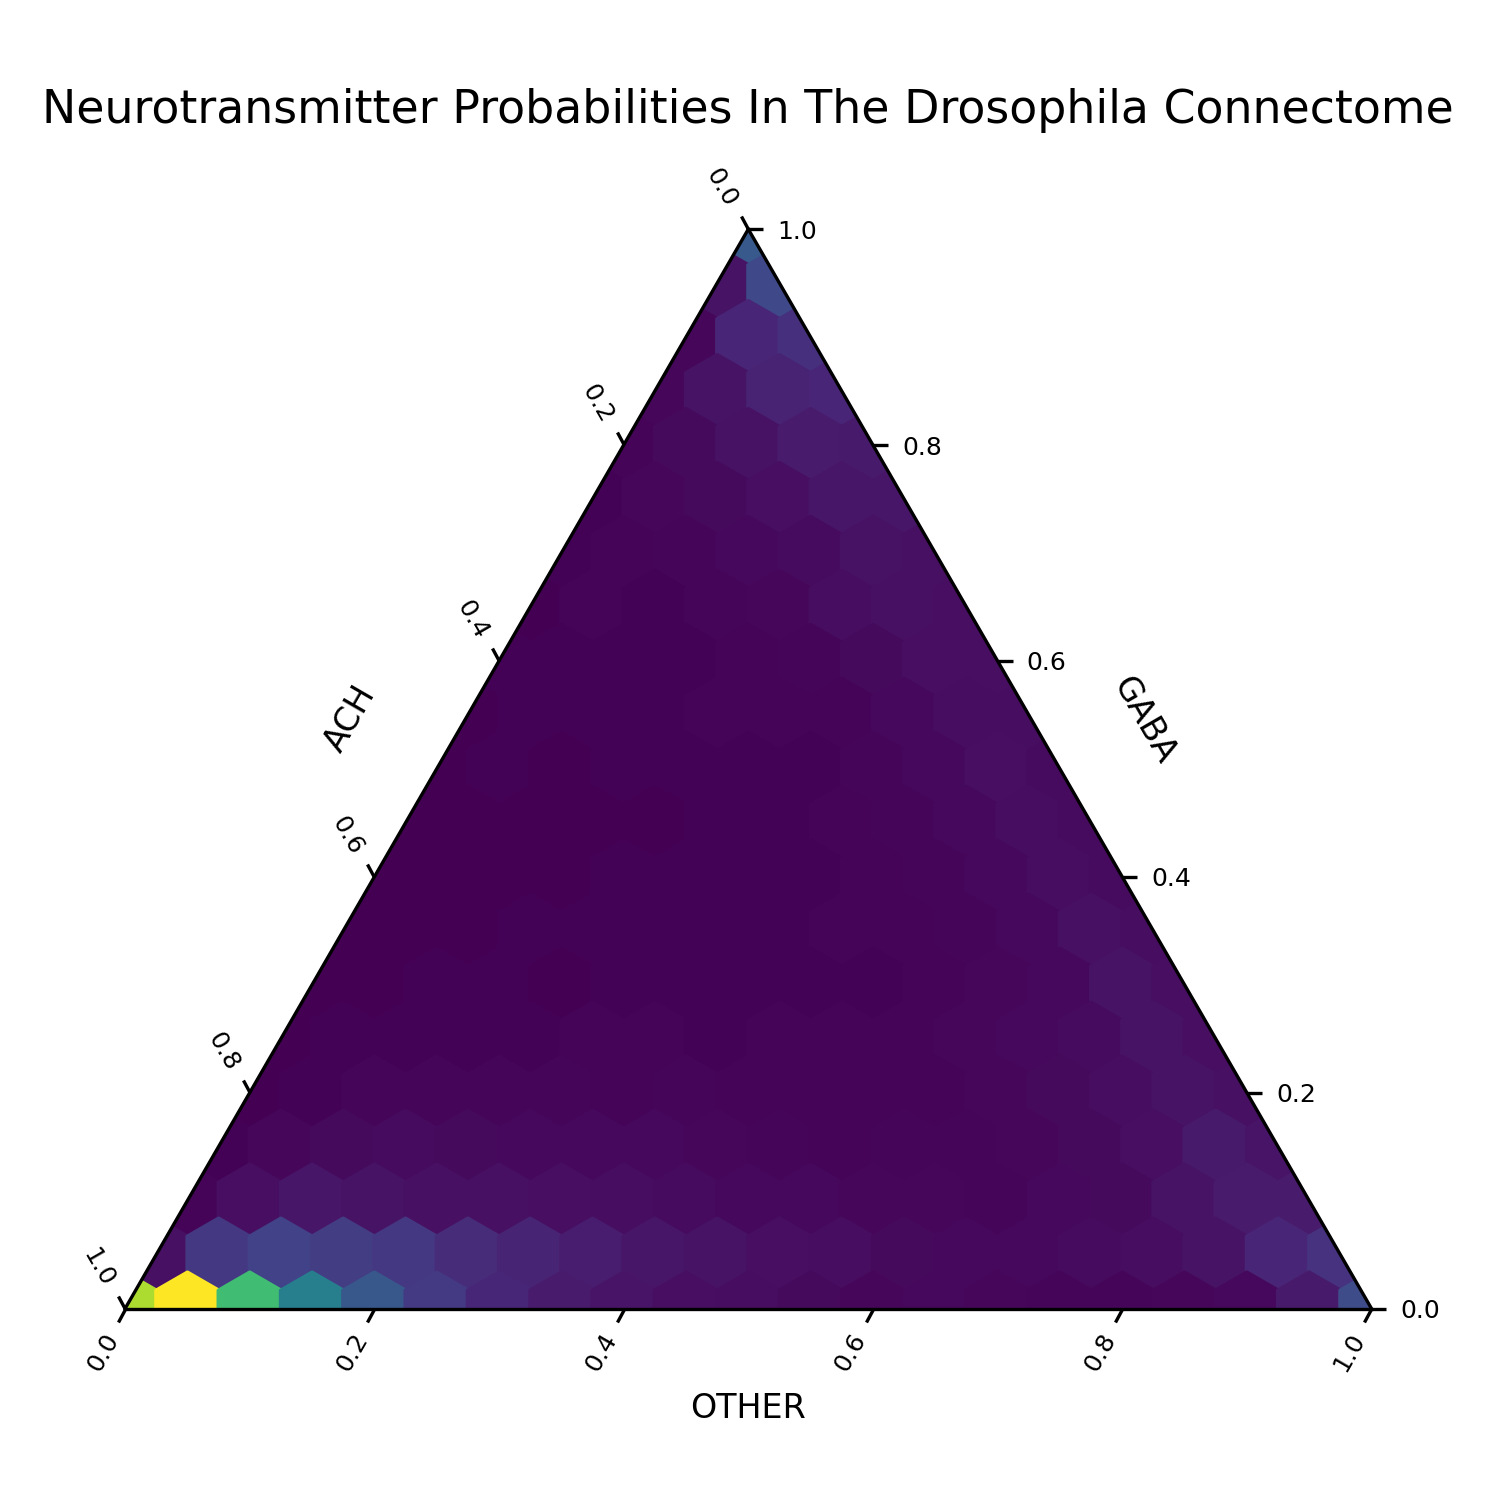

In [13]:
# Sample connectome - hexbin plotting is memory-intensive and don't need every data point to get idea of distribution
sample = pipeline.downsample(connectome_nts, 50_000, allow_bytes)
filename = os.path.join(OUTDIR, "init_overall_distribution.png")
pipeline.make_plot("plot_n_ternary", filename, samples = [sample], labels = ["Neurotransmitter_Probabilities_In_The_Drosophila_Connectome"])
Image(filename, width = 600)

### Divide synapses into 4 initial categories

The above ternary plot shows that the majority of synapses can be categorised as high ACH. Additionally, some can be categorised as high GABA and some as high OTHER. It does appear there may be some synapses that cannot be easily classified into any of these three corner categories. I will classify these as 'unclassified' for now. See the tag_clusters() function in the pipeline script for my choice of cluster boundaries. Note the results may vary slightly with slightly different boundaries.

In [14]:
# Extract and visualise the four initial clusters
connectome = pipeline.tag_clusters(connectome)
sample = pipeline.downsample(connectome, 50_000, allow_bytes)

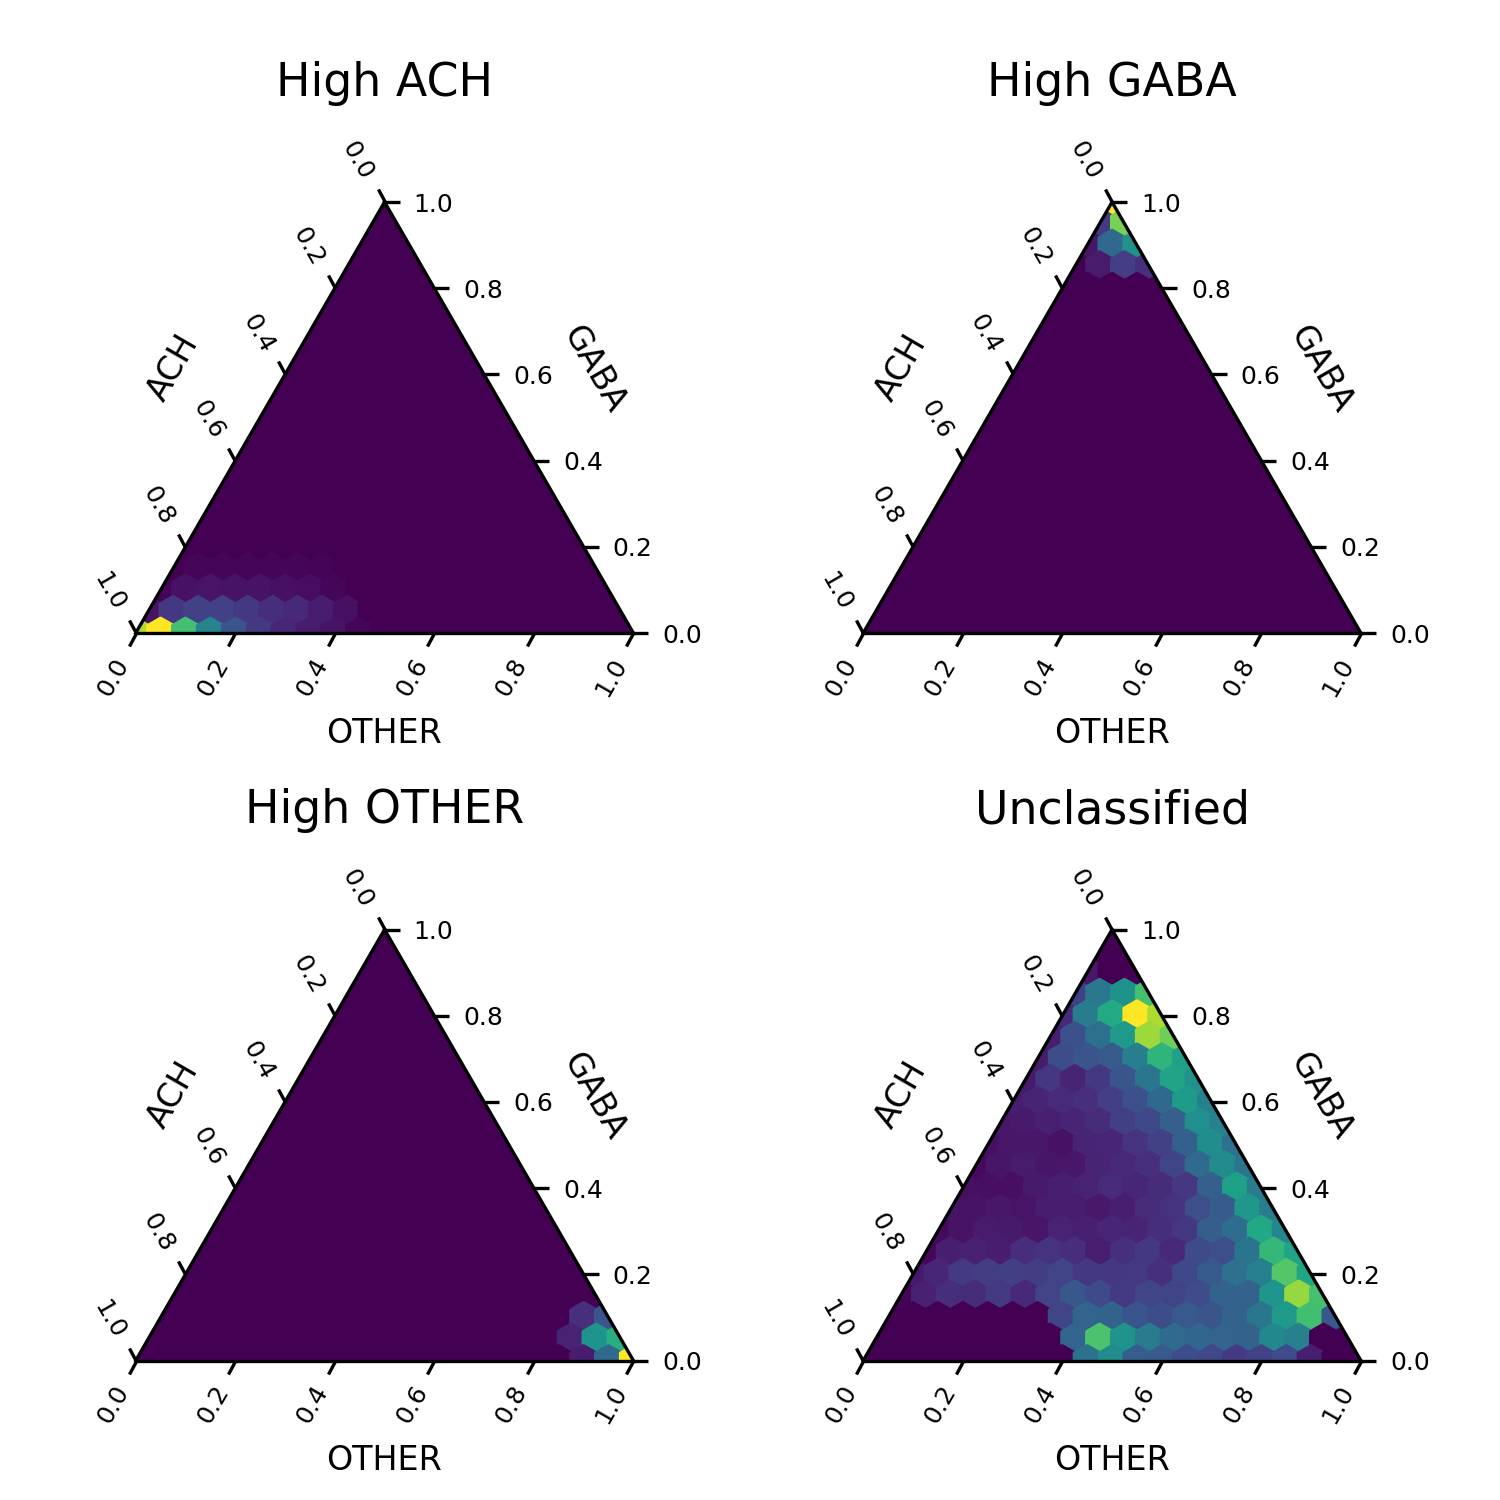

In [15]:
# Plot hex plots of new cluster classifications
grouped = sample.groupby("cluster")
high_gaba_sample = grouped.get_group("gaba")
high_ach_sample = grouped.get_group("ach")
high_other_sample = grouped.get_group("other")
unclassified_sample = grouped.get_group("none")

filename = os.path.join(OUTDIR, "initial_clusters.png")
pipeline.make_plot("plot_n_ternary", filename, 
                   samples = [high_gaba_sample, high_ach_sample, high_other_sample, unclassified_sample], 
                   labels = ["High_GABA", "High_ACH", "High_OTHER", "Unclassified"])
Image(filename, width = 600)

Filtering out the dense regions of the initial distribution reveals an interesting pattern that was previously obscured in unclassified synapses. Most unclassified synapses have ACH < 0.15 or GABA < 0.15. In the context of the dataset, synapse neurotransmitter probabilities not within these ranges are likely due to uncertainty in classification more so than biological significance. Synapses within these ranges may or may not be due to uncertainty as well. Regardless of cause, it will still be interesting to subdivide the unclassified synapses into 3 further categories for further analysis.

### Divide 'Unclassified' Into 3 Further Subdivisions

In [ ]:
# Classify unclassified synapses into gaba_noise, ach_noise, and noise.
# Taking a larger sample this time because I want more power in my analysis.
connectome = pipeline.tag_unclassified_clusters(connectome)
sample = pipeline.downsample(connectome, 500_000, allow_bytes)

In [ ]:
# Plot hex plots of new cluster classifications
grouped = sample.groupby("cluster")
high_gaba_sample = grouped.get_group("gaba")
high_ach_sample = grouped.get_group("ach")
high_other_sample = grouped.get_group("other")
low_ach_noise_sample = grouped.get_group("low_ach_noise")
low_gaba_noise_sample = grouped.get_group("low_gaba_noise")
misc_noise_sample = grouped.get_group("misc_noise")

filename = os.path.join(OUTDIR, "final_clusters.png")
pipeline.make_plot("plot_n_ternary", filename, 
                   samples = [high_gaba_sample, high_ach_sample, high_other_sample, 
                              low_ach_noise_sample, low_gaba_noise_sample, misc_noise_sample], 
                   labels = ["High_GABA", "High_ACH", "High_OTHER",
                             "Low_ACH_Noise", "Low_GABA_Noise", "Misc_Noise"])
Image(filename, width = 600)

### Generate Brain Map

I will use the same data points to generate the brain map as are used to generate the above 6 hex plots. These points will also be used downstream for statistical analysis, so will save to temp file for convenience.

In [ ]:
sample_path = pipeline.make_temp_path()
sample.to_parquet(sample_path) # Create folder containing 1 parquet file per partition

In [ ]:
brain_map_dir = os.path.join(OUTDIR, "brain_map")
pipeline.make_brain_map(sample_path)
IFrame(os.path.join(brain_map_dir, "bm_interactive.html"), width=800, height=600)

## Stage 3: Report & Visualise Neurotransmitter Probability Distributions Across Neuropils

### Summary Statistics For Each Neuropil

In [ ]:
neuropils = pipeline.get_neuropil_summary_stats(connectome)
filename = os.path.join(OUTDIR, "neuropil_summaries.csv")
neuropils.to_csv(filename)
neuropils.head(5) # See csv file for all neuropils

### Mean Neurotransmitter Probabilities With Respect To Neuropil Size

In [ ]:
filename = os.path.join(OUTDIR, "mean_nt_probs_by_neuropil_size.png")
pipeline.make_plot("plot_mean_nt_probs_by_neuropil_size", filename,
                   samples = [neuropils], 
                   labels = [""])

### Neurotransmitter Probability Variances With Respect To Neuropil Size

In [ ]:
filename = os.path.join(OUTDIR, "variance_by_neuropil_size.png")
pipeline.make_plot("plot_variance_by_neuropil_size", filename,
                  samples = [sample], labels = [""])

### Neuropil Neurotransmitter Probability Distributions By Region

## Stage 4: Statistical Analysis

### Neurotransmitter Probabilities Across Different Brain Regions

I want to know whether neurotransmitter probabilities are different between neuropils. Because probabilities are a form of compositional data (the sum of the variables is 1, and each variable is bounded between 0 and 1), the Dirichlet distribution is suitable. This statistical analysis is a simple one based on average synapse probabilities within neuropils. A more statistically robust method would involve using the 'other' column to calculate the ranges of excitatory and inhibitory probabilities for each synaptic connection, then running a statistical analysis that can handle comparing range values within a bounded interval, e.g., Bayesian Dirichlet regression with interval priors. The Dirichlet function I used can only operate on points, not ranges. There does not appear to be an out-of-box Dirichlet regression function in any Python libraries, so I will interface with the R DirichletReg package via rpy2.

### Get Neuropil Summary Statistics

### Run statistical_analysis.R